In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
print(cv2.__version__)       
print(np.__version__)        

5.0.0
2.5.1


In [3]:
import time

def calculate_fps(time_diffs):
    np_array = np.array(time_diffs)
    mean_val = np_array.mean()
    return 1/mean_val

In [4]:
def draw_fps(frame, fps):
    fps_text = f"FPS: {fps:.1f}"
    cv2.putText(
            frame, 
            fps_text, 
            (10, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 
            1, 
            (0, 255, 0),  # Green text
            2, 
            cv2.LINE_AA
        )

In [5]:
def draw_scale_angle(frame, scale, angle):
    cv2.putText(
            frame,
            f"Angle: {angle} deg | Scale: {scale:.4f}",
            (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
        )

In [6]:
def create_mask(bgr_frame):
    # BGR to HSV
    hsv_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2HSV)

    # red
    lower_red01 = np.array([0, 120, 70])
    upper_red01 = np.array([10, 255, 255])
    lower_red02 = np.array([170,120,70])
    upper_red02 = np.array([180,255,255])
    
    mask01 = cv2.inRange(hsv_frame, lower_red01, upper_red01)
    mask02 = cv2.inRange(hsv_frame, lower_red02, upper_red02)
    
    return cv2.bitwise_or(mask01, mask02)

In [7]:
def find_objects(mask):
    # maskClean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)

    threshold = 500
    objects = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < threshold:
            continue
        x, y, w, h = cv2.boundingRect(contour)
        cx = x + w // 2
        cy = y + h // 2
        objects.append((cx, cy, area, (x, y, w, h)))

    return objects

In [8]:
import transform

def pixel_to_world(center_xy, image_size, scale, angle):
    w, h = image_size
    R = transform.rotation_matrix_2d(angle)
    S = transform.scale_matrix_2d(scale, scale)

    rel_position = transform.translate_2d(center_xy, - w / 2.0, - h / 2.0) # translation
    scaled = S @ rel_position # scaling
    angled = R @ scaled # rotation
    return angled

In [9]:
def draw_detection(frame, detected_objects, image_size, scale, angle):
    wx = wy = None
    for cx, cy, area, (x, y, w, h) in detected_objects:

        greenBGR = (0, 255, 0)
        thickness = 2
        cv2.rectangle(frame, (x, y), (x + w, y + h), greenBGR, thickness)

        redBGR = (0,0,255)
        radius = 4
        cv2.circle(frame, (cx, cy), radius, redBGR, -1)

        wx, wy = pixel_to_world((cx, cy), image_size, scale, angle)
        text = f"px({cx}, {cy})\nworld({wx:.2f}, {wy:.2f})"
        text_position = (cx + 20, cy)
        
        cv2.putText(
            frame,
            text,
            text_position,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            redBGR,
            1,
            cv2.LINE_AA
        )

    return frame, (wx, wy)        

In [10]:
def detect(frame, image_size, scale, angle):
    masked = create_mask(frame) # white objects, black background
    detected_objects = find_objects(masked) # detect boundaries
    if not detected_objects:
        return (frame, masked, [], None, None)
    largest = [max(detected_objects, key=lambda o: o[2])]
    result, world_coor = draw_detection(frame, largest, image_size, scale, angle) # draw bounding boxes on the original frame

    # largest[0] is (cx, cy, area, (x, y, w, h))
    pixel_coor = (largest[0][0], largest[0][1])
    # print(f"중심: ({world_coor[0]}, {world_coor[1]}) | 면적: {largest[0][2]}px²")
    return (result, masked, detected_objects, pixel_coor, world_coor)

In [11]:
from collections import deque

In [20]:
def main():
    # ---------------- Camera Initialization ----------------
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("카메라를 열 수 없습니다.")
        sys.exit()

    print("웹캠 연결 성공")


    width = 640
    height = 480
    image_size = (width, height)

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)

    
    # ---------------- Coordinate History ----------------
    pixel_coor_list = deque(maxlen=100)
    world_coor_list = deque(maxlen=100)

    # ---------------- FPS ----------------
    time_diffs = deque(maxlen=30)
    previous_time = time.time()

    # ---------------- Plot ----------------
    plt.ion()
    fig, ax = plt.subplots()
 
    ax.set_title("Pixel & World Coordinates")
    pixel_sc = ax.scatter([], [], color='blue', label='Pixel')
    world_sc  = ax.scatter([], [], color='red', label='World')

    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.legend()


    frame_count = 0
    scale = 0.01
    angle = 0

    # ======================================================
    # Main Loop
    # ======================================================
    while True:

        # ---------- sense start ---------- #
        sense_start = time.time()
        
        ret, frame = cap.read()
        if not ret:
            print("프레임을 가져올 수 없습니다.")
            break

        # ---------- sense end ---------- #
        sense_elapsed = time.time() - sense_start

        frame_count += 1

        # ---------- compute start ---------- #
        compute_start = time.time()

        result, mask, objects, pixel_coor, world_coor = detect(
            frame.copy(), image_size, scale, angle
        )

        # ---------- compute end ---------- #
        compute_elapsed = time.time() - compute_start

        
        # ---------- act start ---------- #
        act_start = time.time()

        time_diffs.append(act_start - previous_time)
        previous_time = act_start

        if len(time_diffs) == time_diffs.maxlen:
            fps = calculate_fps(time_diffs)
            draw_fps(result, fps)

        if pixel_coor is not None:
            pixel_coor_list.append(pixel_coor)
            world_coor_list.append(world_coor)

            # print(f"pixel: {pixel_coor} | world: ({world_coor[0]:.2f}, {world_coor[1]:.2f})")
            
        if frame_count % 3 == 0 and len(pixel_coor_list) == pixel_coor_list.maxlen:
            pixel_sc.set_offsets(pixel_coor_list)
            world_sc.set_offsets(world_coor_list)
 
            plt.draw()
            plt.pause(0.001)
        
        draw_scale_angle(result, scale, angle)

        cv2.imshow("Result", result)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
          break
        elif key == ord("a"):
          angle -= 5
        elif key == ord("d"):
          angle += 5
        elif key == ord("+") or key == ord("="):
          scale *= 1.1
        elif key == ord("-") or key == ord("_"):
          scale *= 0.9

        # ---------- act end ---------- #
        act_elapsed = time.time() - act_start

        if len(time_diffs) == time_diffs.maxlen and frame_count % 100 == 0:
            sense_ms = sense_elapsed * 1000
            compute_ms = compute_elapsed * 1000
            act_ms = act_elapsed * 1000
            
            text_process = f"sense: {sense_ms:.1f}ms | compute: {compute_ms:.1f}ms | act: {act_ms:.1f}ms | FPS: {fps:.1f}"
            print(text_process)

    cap.release()
    cv2.destroyAllWindows()

웹캠 연결 성공
sense: 10.9ms | compute: 5.4ms | act: 2.2ms | FPS: 28.8
sense: 19.1ms | compute: 1.1ms | act: 11.7ms | FPS: 30.7
sense: 16.1ms | compute: 5.7ms | act: 9.2ms | FPS: 29.9


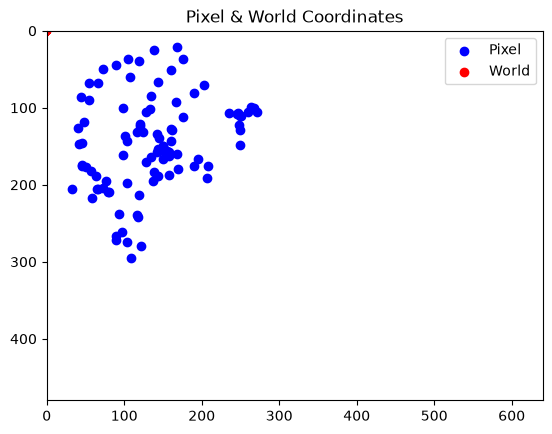

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

sense: 4.1ms | compute: 10.2ms | act: 2.0ms | FPS: 18.4


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [21]:
if __name__ == "__main__":
    main()